# Lab 3 — Two Moons Classification

Lab 1 and Lab 2 trained on the 4-point AND/XOR gates. This lab trains the same
kind of hidden-layer network — `2 inputs -> 8 hidden (sigmoid) -> 1 output
(sigmoid)` — on the two-moons dataset (`two_moons_train.csv` /
`two_moons_val.csv`): 700 training points and 300 validation points arranged
in two interleaved crescents. It then shows the model's predictions both as
per-point numbers and as a decision boundary dividing the crescents.


In [1]:
import csv
import random
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt

from neural_network.activations import ACTIVATIONS
from neural_network.hyperparameters import random_weights, zero_bias
from neural_network.layer import Layer
from neural_network.network import Network
from trainer.reporter import Reporter
from trainer.trainer import Trainer
from visualizer import MoonsVisualizer, TrainingVisualizer


def load_two_moons(path):
    inputs, targets = [], []
    with open(path, newline="") as file:
        for x1, x2, label in csv.reader(file):
            inputs.append([float(x1), float(x2)])
            targets.append([float(label)])
    return inputs, targets


train_inputs, train_targets = load_two_moons(REPO_ROOT / "lab3" / "two_moons_train.csv")
val_inputs, val_targets = load_two_moons(REPO_ROOT / "lab3" / "two_moons_val.csv")
len(train_inputs), len(val_inputs)

(700, 300)

## Training

In [2]:
random.seed(1)

hidden_layer = Layer.build(
    input_size=2, output_size=8,
    weight=random_weights(input_size=2, output_size=8), bias=zero_bias(8),
    activation_function=ACTIVATIONS.SIGMOID.function,
    activation_derivative=ACTIVATIONS.SIGMOID.derivative,
)
output_layer = Layer.build(
    input_size=8, output_size=1,
    weight=random_weights(input_size=8, output_size=1), bias=zero_bias(1),
    activation_function=ACTIVATIONS.SIGMOID.function,
    activation_derivative=ACTIVATIONS.SIGMOID.derivative,
)
moons_network = Network(hidden_layer, output_layer)

moons_trainer = Trainer(moons_network)
moons_trainer.train(train_inputs, train_targets, val_inputs, val_targets)

Epoch: 100/500 | Error: 0.0029 | Accuracy: 99.86% | Val Error: 0.0076 | Val Accuracy: 99.00%
Epoch: 200/500 | Error: 0.0004 | Accuracy: 100.00% | Val Error: 0.0076 | Val Accuracy: 99.33%
Epoch: 300/500 | Error: 0.0002 | Accuracy: 100.00% | Val Error: 0.0072 | Val Accuracy: 99.33%
Epoch: 400/500 | Error: 0.0001 | Accuracy: 100.00% | Val Error: 0.0071 | Val Accuracy: 99.33%
Epoch: 500/500 | Error: 0.0001 | Accuracy: 100.00% | Val Error: 0.0070 | Val Accuracy: 99.33%
Reached maximum epochs without meeting the error threshold.

Final Epoch:
Epoch: 500/500 | Error: 0.0001 | Accuracy: 100.00% | Val Error: 0.0070 | Val Accuracy: 99.33%


## Training history

Loss and accuracy per epoch for both the training set and the validation set,
which is evaluated after every epoch without being trained on.

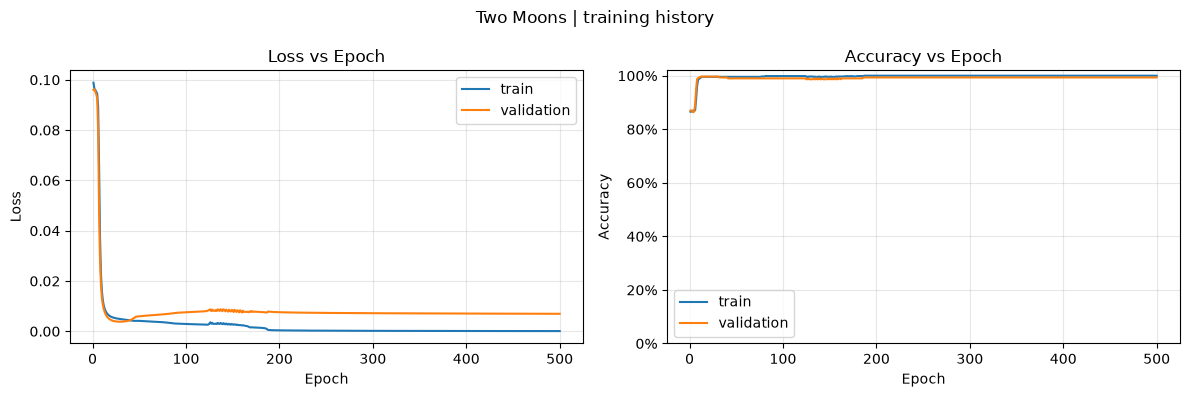

In [3]:
TrainingVisualizer().plot(moons_trainer, title="Two Moons | training history")

## Predictions

With 700/300 points, printing every prediction isn't useful, so this shows
error and accuracy over the full train/val sets plus a handful of individual
predictions with `Reporter.prediction`.

In [4]:
train_error, train_accuracy = moons_trainer.evaluate(train_inputs, train_targets)
val_error, val_accuracy = moons_trainer.evaluate(val_inputs, val_targets)

Reporter.evaluation(f"Train ({len(train_inputs)} points)", train_error, train_accuracy)
Reporter.evaluation(f"Val   ({len(val_inputs)} points)", val_error, val_accuracy)

Train (700 points) | Error: 0.0001 | Accuracy: 100.00%
Val   (300 points) | Error: 0.0070 | Accuracy: 99.33%


In [5]:
print("Sample validation predictions:")
for point, target in zip(val_inputs[:10], val_targets[:10]):
    prediction = moons_network.forward(point)
    Reporter.prediction(point, target, prediction)

Sample validation predictions:
Inputs: [-0.0261, -1.0049] | Target: [1.0000] | Prediction: [0.9964]
Inputs: [1.3053, -0.8260] | Target: [1.0000] | Prediction: [0.9998]
Inputs: [1.7595, 0.2491] | Target: [1.0000] | Prediction: [1.0000]
Inputs: [0.0386, 1.4773] | Target: [0.0000] | Prediction: [0.0015]
Inputs: [0.6050, -1.9715] | Target: [1.0000] | Prediction: [1.0000]
Inputs: [1.0348, -0.9287] | Target: [1.0000] | Prediction: [0.9996]
Inputs: [0.8970, -1.4277] | Target: [1.0000] | Prediction: [0.9997]
Inputs: [-1.0685, 1.3449] | Target: [0.0000] | Prediction: [0.0003]
Inputs: [-0.2716, -1.3415] | Target: [1.0000] | Prediction: [0.9964]
Inputs: [-0.0643, -1.1114] | Target: [1.0000] | Prediction: [0.9970]


## Decision boundary

`MoonsVisualizer` plots the predicted regions across the whole input plane —
the boundary line dividing the two crescents — with any misclassified points
circled in red.

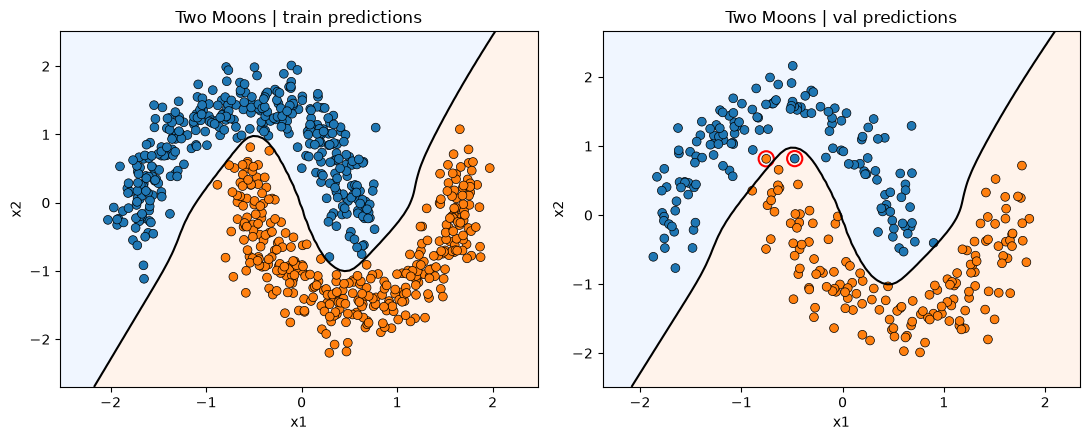

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
MoonsVisualizer().plot(moons_network, train_inputs, train_targets, title="Two Moons | train predictions", ax=axes[0])
MoonsVisualizer().plot(moons_network, val_inputs, val_targets, title="Two Moons | val predictions", ax=axes[1])
fig.tight_layout()